In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import cv2
import seaborn as sns
import keras
import keras_tuner as kt

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"

# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "cnn_weighted_model.h5"

### CLAHE PREPROCESSING

In [3]:
# def apply_clahe(img):
#     img = img.astype(np.uint8)

#     lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#     l, a, b = cv2.split(lab)

#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#     l = clahe.apply(l)

#     lab = cv2.merge((l, a, b))
#     img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

#     return img


# def process_and_save_clahe(input_root, output_root, img_size=(96,96)):
#     for split in ["Train", "Test"]:
#         split_path = os.path.join(input_root, split)

#         for class_name in os.listdir(split_path):
#             class_path = os.path.join(split_path, class_name)

#             if not os.path.isdir(class_path):
#                 continue

#             save_class_path = os.path.join(output_root, split, class_name)
#             os.makedirs(save_class_path, exist_ok=True)

#             for img_name in os.listdir(class_path):
#                 if img_name.startswith("."):
#                     continue

#                 img_path = os.path.join(class_path, img_name)

#                 img = cv2.imread(img_path)
#                 if img is None:
#                     continue

#                 img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                 img = cv2.resize(img, img_size)

#                 img = apply_clahe(img)

#                 img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

#                 save_path = os.path.join(save_class_path, img_name)
#                 cv2.imwrite(save_path, img)

#     print("CLAHE train and test dataset saved!")

### UNSHARP MASKING PREPROCESSING

In [4]:
# def unsharp_mask(img, sigma=1.0, amount=1.2):
#     # calculates the optimal kernel size (w,h) from the provided sigma.
#     blurred = cv2.GaussianBlur(img, (0,0), sigma)
#     # 1 + amount (alpha): The weight given to the original image
#     # -amount (beta): The weight given to the blurred image
#     # gamma at 0 (no brightness adjustment)
#     sharp = cv2.addWeighted(img, 1+amount, blurred, -amount, 0)
#     return sharp

# def process_and_save_mask(input_root, output_root, img_size=(96,96)):
#     for split in ["Train"]:
#         split_path = os.path.join(input_root, split)

#         for class_name in os.listdir(split_path):
#             class_path = os.path.join(split_path, class_name)

#             if not os.path.isdir(class_path):
#                 continue

#             save_class_path = os.path.join(output_root, split, class_name)
#             os.makedirs(save_class_path, exist_ok=True)

#             for img_name in os.listdir(class_path):
#                 if img_name.startswith("."):
#                     continue

#                 img_path = os.path.join(class_path, img_name)

#                 img = cv2.imread(img_path)
#                 if img is None:
#                     continue

#                 img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                 img = cv2.resize(img, img_size)

#                 img = unsharp_mask(img)

#                 img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

#                 save_path = os.path.join(save_class_path, img_name)
#                 cv2.imwrite(save_path, img)

#     print("Mask train dataset saved: ", output_root)

In [5]:
# process_and_save_clahe(ORIGINAL_DATA_PATH, CLAHE_DATASET_PATH, img_size=IMG_SIZE)
# process_and_save_mask(ORIGINAL_DATA_PATH, MASK_DATASET_PATH, img_size=IMG_SIZE)

In [6]:
# TRAIN_CLAHE_DATA_PATH = "../clahe_dataset/Train"
# TEST_CLAHE_DATA_PATH = "../clahe_dataset/Test"
# TRAIN_MASK_DATA_PATH = "../mask_dataset/Train"
# TEST_MASK_DATA_PATH = "../mask_dataset/Test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

In [5]:
train_dataset = train_datagen.flow_from_directory(
    TRAIN_DATA_PATH,
    subset="training",
    seed = RANDOM_SEED,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode = "sparse"
)

val_dataset = train_datagen.flow_from_directory(
    TRAIN_DATA_PATH,
    seed = RANDOM_SEED,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode = "sparse",
    shuffle=False,
    subset="validation"
)
test_dataset = test_datagen.flow_from_directory(
    TEST_DATA_PATH,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode = "sparse"
)

Found 12890 images belonging to 8 classes.
Found 3218 images belonging to 8 classes.
Found 14518 images belonging to 8 classes.


In [9]:
print(train_dataset.classes)
print(train_dataset.class_indices.values())
train_labels=train_dataset.classes
print(np.unique(train_labels))

[0 0 0 ... 7 7 7]
dict_values([0, 1, 2, 3, 4, 5, 6, 7])
[0 1 2 3 4 5 6 7]


In [72]:
'''
Calculate class weights for imbalanced dataset
Create label list manually from folder counts
Class weights змушують loss сильніше штрафувати помилки на rare classes.
'''

train_labels = train_dataset.classes

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_arr))
# class_weights = dict(zip(np.unique(class_weights_arr), class_weights_arr))
print(class_weights)

{0: np.float64(1.3427083333333334), 1: np.float64(1.291065705128205), 2: np.float64(1.63744918699187), 3: np.float64(1.3316115702479339), 4: np.float64(0.8607104700854701), 5: np.float64(0.7300634345265066), 6: np.float64(0.6515365952284674), 7: np.float64(0.9500294811320755)}


In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

### Keras_tuner: Hyperparameter Tuning

In [12]:
# def build_model(hp):
#     model = tf.keras.Sequential([
#         layers.Input(shape=(*IMG_SIZE, 3)),
#         data_augmentation,
#         # Block 1
#         layers.Conv2D(hp.Choice('filters1', [32,64]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters2', [32,64]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.MaxPooling2D(),
#         layers.Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)),

#         # Block 2
#         layers.Conv2D(hp.Choice('filters3', [64,128]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Conv2D(hp.Choice('filters4', [64,128]), (3,3), padding='same'),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.MaxPooling2D(),
#         layers.Dropout(hp.Float('dropout2',min_value=0.1, max_value=0.5, step=0.1)),

#         layers.GlobalAveragePooling2D(),

#         layers.Dense(
#             units=hp.Int('units', min_value=32, max_value=256, step=32),
#             kernel_regularizer=tf.keras.regularizers.l2(
#                 hp.Float('l2', 1e-5, 1e-3, sampling='log')
#             )
#         ),
#         layers.BatchNormalization(),
#         layers.Activation('relu'),
#         layers.Dropout(hp.Float('dropout3',min_value=0.1, max_value=0.5, step=0.1)),

#         layers.Dense(8,activation='softmax')
#     ])
#     model.compile(
#         loss='sparse_categorical_crossentropy',
#         optimizer=AdamW(hp.Float('lr',min_value=1e-5, max_value=1e-3, sampling='log')),
#         metrics=['accuracy']
#     )
#     return model

In [16]:
def build_model(hp):
    model = tf.keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        # Block 1
        layers.Conv2D(hp.Choice('filters1', [32,64]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters2', [32,64]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters3', [32,64]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)),

        # Block 2
        layers.Conv2D(hp.Choice('filters4', [64,128]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters5', [64,128]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters6', [64,128]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)),

        # Block 3
        layers.Conv2D(hp.Choice('filters7', [128,256]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters8', [128,256]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(hp.Choice('filters9', [128,256]), (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.5, step=0.1)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            2048,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_1', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(hp.Float('dropout4',min_value=0.1, max_value=0.5, step=0.1)),
        
        layers.Dense(1024,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_2', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(hp.Float('dropout5',min_value=0.1, max_value=0.5, step=0.1)),
        
        layers.Dense(512,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_3', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(hp.Float('dropout6',min_value=0.1, max_value=0.5, step=0.1)),
        
        layers.Dense(8,activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=AdamW(hp.Float('lr',min_value=1e-5, max_value=1e-3, sampling='log')),
        metrics=['accuracy']
    )
    return model

In [28]:
'''
Initialize a tuner (here, HyperBand). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3, # Reduction factor 3x fewer models in the next round
    directory='keras_tuner_results',
    project_name='emotion_recognition'
)

Reloading Tuner from keras_tuner_results\emotion_recognition\tuner0.json


In [29]:
tuner.search_space_summary()

Search space summary
Default search space size: 8
filters1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
l2 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [30]:
tuner.search(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

In [31]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = build_model(best_hp)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             

 Total params: 3,407,656 (13.00 MB)

 Trainable params: 3,399,080 (12.97 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [33]:
best_hp.values

{'filters1': 32,
 'dropout1': 0.1,
 'filters2': 64,
 'dropout2': 0.1,
 'units': 160,
 'l2': 4.668234933893038e-05,
 'dropout3': 0.1,
 'lr': 0.001879924731863074,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0,
 'filters3': 32,
 'filters4': 64,
 'filters5': 64,
 'filters6': 64,
 'filters7': 128,
 'filters8': 128,
 'filters9': 128,
 'l2_1': 1e-05,
 'dropout4': 0.1,
 'l2_2': 1e-05,
 'dropout5': 0.1,
 'l2_3': 1e-05,
 'dropout6': 0.1}

In [27]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\emotion_recognition
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0028 summary
Hyperparameters:
filters1: 32
dropout1: 0.1
filters2: 64
dropout2: 0.1
units: 160
l2: 4.668234933893038e-05
dropout3: 0.1
lr: 0.001879924731863074
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
filters3: 32
filters4: 64
filters5: 64
filters6: 64
filters7: 128
filters8: 128
filters9: 128
l2_1: 1e-05
dropout4: 0.1
l2_2: 1e-05
dropout5: 0.1
l2_3: 1e-05
dropout6: 0.1
Score: 0.44095712900161743

Trial 0027 summary
Hyperparameters:
filters1: 64
dropout1: 0.1
filters2: 128
dropout2: 0.1
units: 256
l2: 6.098704335687211e-05
dropout3: 0.4
lr: 0.0005742266362534293
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.4294593036174774

Trial 0024 summary
Hyperparameters:
filters1: 64
dropout1: 0.2
filters2: 128
dropout2: 0.5
units: 192
l2: 2.7861363026877764e-05
dropout3: 0.300000000000000

In [28]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('cnn_weighted_loss_training_log.csv')
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,    
    min_lr=1e-6
)

In [29]:
start = time.time()
history = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, rlr, csv_logger]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.1298 - loss: 2.3012

403/403 ━━━━━━━━━━━━━━━━━━━━ 166s 402ms/step - accuracy: 0.1370 - loss: 2.2253 - val_accuracy: 0.1053 - val_loss: 8.6893 - learning_rate: 0.0019
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.1430 - loss: 2.1978

403/403 ━━━━━━━━━━━━━━━━━━━━ 161s 401ms/step - accuracy: 0.1420 - loss: 2.1760 - val_accuracy: 0.1122 - val_loss: 2.2041 - learning_rate: 0.0019
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.1600 - loss: 2.1473

403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.1637 - loss: 2.1384 - val_accuracy: 0.1156 - val_loss: 2.1916 - learning_rate: 0.0019
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.1704 - loss: 2.1312

403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.1690 - loss: 2.1202 - val_accuracy: 0.1311 - val_loss: 2.1149 - learning_rate: 0.0019
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 156s 388ms/step - accuracy: 0.1542 - loss: 2.1338 - val_accuracy: 0.1265 - val_loss: 2.1595 - learning_rate: 0.0019
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.1535 - loss: 2.1131

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6296 - loss: 1.0429 - val_accuracy: 0.6383 - val_loss: 0.9656 - learning_rate: 0.0019
Epoch 46/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6312 - loss: 1.0314 - val_accuracy: 0.6004 - val_loss: 1.0802 - learning_rate: 0.0019
Epoch 47/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 158s 393ms/step - accuracy: 0.6417 - loss: 1.0265 - val_accuracy: 0.5643 - val_loss: 1.4319 - learning_rate: 0.0019
Epoch 48/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6417 - loss: 1.0207 - val_accuracy: 0.6035 - val_loss: 1.1336 - learning_rate: 0.0019
Epoch 49/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 393ms/step - accuracy: 0.6469 - loss: 1.0078 - val_accuracy: 0.5904 - val_loss: 1.0716 - learning_rate: 0.0019
Epoch 50/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.6439 - loss: 1.0048

403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6476 - loss: 0.9976 - val_accuracy: 0.6538 - val_loss: 0.9456 - learning_rate: 0.0019
Epoch 51/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 158s 392ms/step - accuracy: 0.6524 - loss: 0.9918 - val_accuracy: 0.6162 - val_loss: 1.0001 - learning_rate: 0.0019
Epoch 52/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 160s 397ms/step - accuracy: 0.6607 - loss: 0.9754 - val_accuracy: 0.5709 - val_loss: 1.2650 - learning_rate: 0.0019
Epoch 53/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6635 - loss: 0.9729 - val_accuracy: 0.5525 - val_loss: 1.1264 - learning_rate: 0.0019
Epoch 54/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6581 - loss: 0.9799 - val_accuracy: 0.5733 - val_loss: 1.2268 - learning_rate: 0.0019
Epoch 55/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 158s 393ms/step - accuracy: 0.6684 - loss: 0.9549 - val_accuracy: 0.6339 - val_loss: 1.0005 - learning_rate: 0.0019
Epoch 56/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accurac

403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.6936 - loss: 0.8909 - val_accuracy: 0.6687 - val_loss: 0.9091 - learning_rate: 5.6398e-04
Epoch 57/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 159s 395ms/step - accuracy: 0.7047 - loss: 0.8689 - val_accuracy: 0.6666 - val_loss: 0.9065 - learning_rate: 5.6398e-04
Epoch 58/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 160s 398ms/step - accuracy: 0.7063 - loss: 0.8516 - val_accuracy: 0.6594 - val_loss: 0.9232 - learning_rate: 5.6398e-04
Epoch 59/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.6964 - loss: 0.8532

403/403 ━━━━━━━━━━━━━━━━━━━━ 160s 396ms/step - accuracy: 0.7040 - loss: 0.8469 - val_accuracy: 0.6824 - val_loss: 0.8783 - learning_rate: 5.6398e-04
Epoch 60/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 403ms/step - accuracy: 0.7052 - loss: 0.8504 - val_accuracy: 0.6610 - val_loss: 0.9242 - learning_rate: 5.6398e-04
Epoch 61/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 163s 404ms/step - accuracy: 0.7112 - loss: 0.8321 - val_accuracy: 0.6694 - val_loss: 0.9029 - learning_rate: 5.6398e-04
Epoch 62/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 403ms/step - accuracy: 0.7132 - loss: 0.8246 - val_accuracy: 0.6489 - val_loss: 0.9629 - learning_rate: 5.6398e-04
Epoch 63/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 402ms/step - accuracy: 0.7132 - loss: 0.8247 - val_accuracy: 0.6492 - val_loss: 0.9531 - learning_rate: 5.6398e-04
Epoch 64/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.7106 - loss: 0.8146

403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.7126 - loss: 0.8182 - val_accuracy: 0.6846 - val_loss: 0.8940 - learning_rate: 5.6398e-04
Epoch 65/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.7286 - loss: 0.7940 - val_accuracy: 0.6669 - val_loss: 0.9155 - learning_rate: 1.6919e-04
Epoch 66/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 402ms/step - accuracy: 0.7249 - loss: 0.7849 - val_accuracy: 0.6709 - val_loss: 0.9160 - learning_rate: 1.6919e-04
Epoch 67/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 163s 405ms/step - accuracy: 0.7280 - loss: 0.7758 - val_accuracy: 0.6675 - val_loss: 0.9117 - learning_rate: 1.6919e-04
Epoch 68/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 161s 400ms/step - accuracy: 0.7322 - loss: 0.7644 - val_accuracy: 0.6784 - val_loss: 0.9058 - learning_rate: 1.6919e-04
Epoch 69/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 162s 401ms/step - accuracy: 0.7316 - loss: 0.7702 - val_accuracy: 0.6750 - val_loss: 0.9033 - learning_rate: 1.6919e-04
Training time:  03:04:17


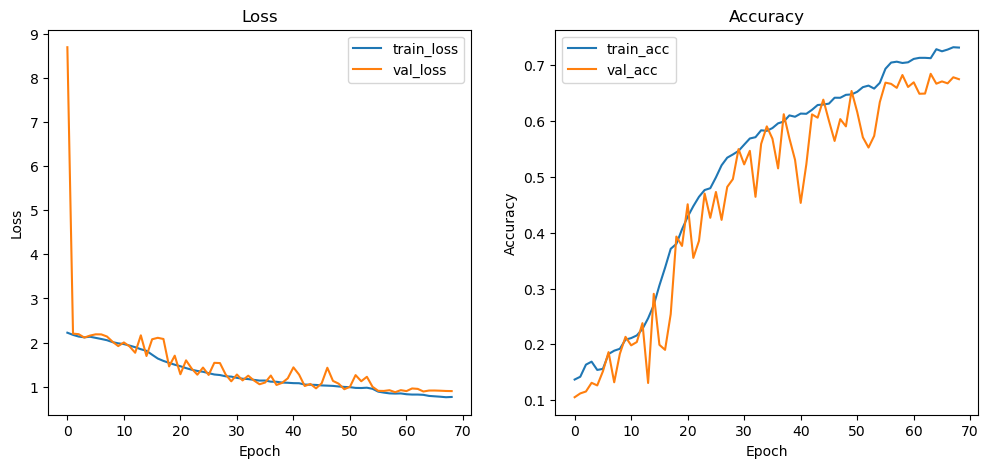

In [30]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [17]:
model = tf.keras.models.load_model(SAVED_MODEL)

In [32]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

454/454 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.6528 - loss: 1.9604
Test Accuracy: 65.28%


Evaluating on Test Set...
454/454 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.6528 - loss: 1.9604
Test Accuracy: 65.28%
Generating predictions...
454/454 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step

Classification Report:

              precision    recall  f1-score   support

       anger       0.57      0.46      0.51      1718
    contempt       0.63      0.64      0.64      1312
     disgust       0.52      0.49      0.50      1248
        fear       0.64      0.41      0.50      1664
       happy       0.92      0.89      0.90      2704
     neutral       0.70      0.95      0.81      2368
         sad       0.54      0.62      0.58      1584
    surprise       0.48      0.47      0.48      1920

    accuracy                           0.65     14518
   macro avg       0.62      0.62      0.61     14518
weighted avg       0.65      0.65      0.64     14518



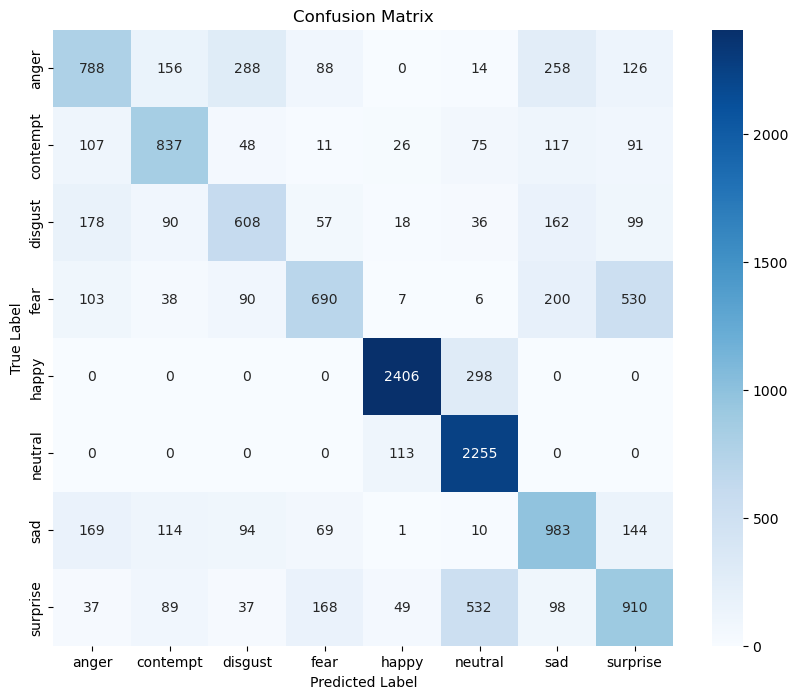

In [33]:
def report_test_results():
    print("Evaluating on Test Set...")
    # Evaluate returns [loss, accuracy]
    loss, accuracy = model.evaluate(test_dataset)
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    # Make predictions
    print("Generating predictions...")

    # generator reset to start from the beginning (important for correct label alignment)
    test_dataset.reset()
    predictions = model.predict(test_dataset, verbose=1)

    # Convert predictions to class indexes
    y_pred_indices = np.argmax(predictions, axis=1)

    # Get true labels directly from the generator
    y_true_indices = test_dataset.classes

    # Get the class names (labels)
    class_labels = list(test_dataset.class_indices.keys())

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true_indices, y_pred_indices, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true_indices, y_pred_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# noisy labels (many classes mix up emotion classification)
report_test_results()

In [68]:
CLASSES = list(test_dataset.class_indices.keys())
CLASSES


['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [69]:
predictions = model.predict(test_dataset, verbose=1)

# Convert predictions to class indexes
y_pred_indices = np.argmax(predictions, axis=1)

# Get true labels directly from the generator
y_true_indices = test_dataset.classes

# axis 0 and axis 1 depend on the shape of predictions (num_samples, num_classes)
confidence = np.max(predictions, axis=1)
print("Confidence scores for predictions: ", confidence)

wrong_idx = np.where(y_pred_indices != y_true_indices)[0]
print("Total wrong predictions: ", len(wrong_idx))

high_confidence_wrong_idx = wrong_idx[confidence[wrong_idx] > 0.8]
print("High confidence wrong predictions: ", len(high_confidence_wrong_idx))

454/454 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step
Confidence scores for predictions:  [0.38104722 0.41613436 0.6128888  ... 0.9624413  0.8373136  0.55778235]
Total wrong predictions:  5041
High confidence wrong predictions:  1319


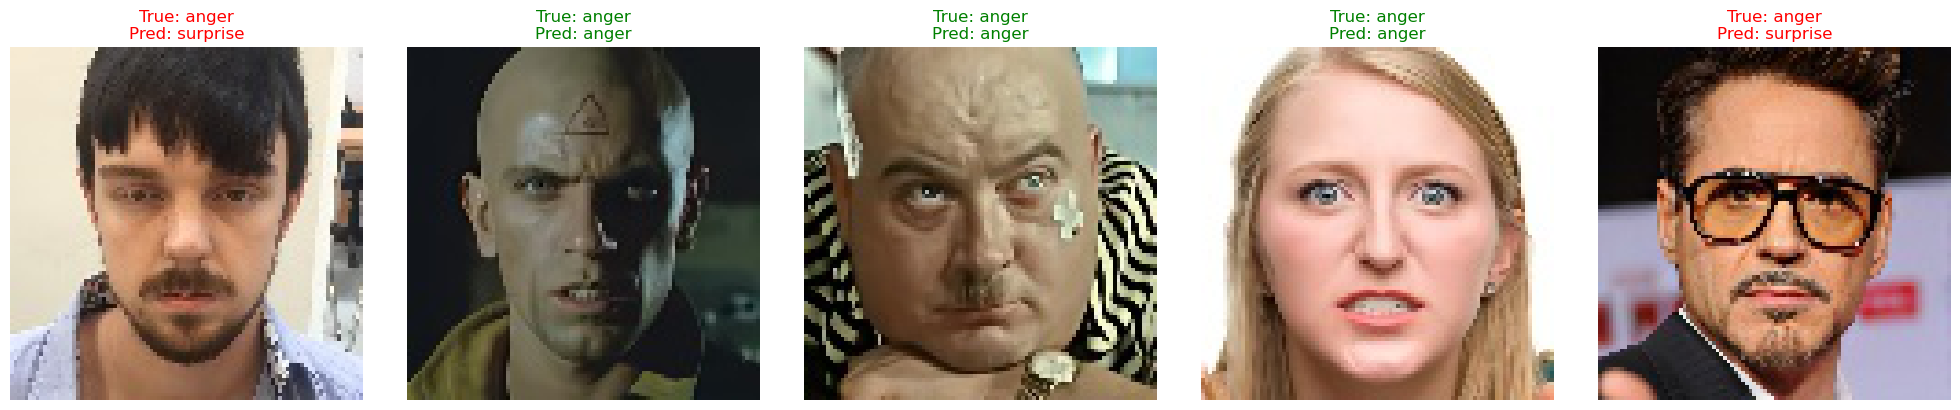

In [70]:
def predict_random_samples():

    # Get one batch
    images, labels = next(iter(test_dataset))

    # Random 5 images
    indices = np.random.choice(len(images), 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):

        img = images[i]
        # True label
        true_idx = int(labels[idx])
        true_label = CLASSES[true_idx]

        # Prediction
        pred_prob = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Plot image
        axes[i].imshow((img * 255).astype(np.uint8))
        axes[i].axis("off")

        # Color
        color = 'green' if true_idx == pred_idx else 'red'

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_random_samples()